<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Walmart.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data = data.sort_values('Date').reset_index(drop=True)
data['Date'] = data['Date'].dt.strftime('%d-%m-%Y')  # keep string format for downstream EDA cells

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,10,05-02-2010,2193048.75,0,54.34,2.962,126.442065,9.765
2,37,05-02-2010,536006.73,0,45.97,2.572,209.852966,8.554
3,17,05-02-2010,789036.02,0,23.11,2.666,126.442065,6.548
4,30,05-02-2010,465108.52,0,39.05,2.572,210.752605,8.324


In [6]:
data.shape

(6435, 8)

In [7]:
data.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


### Feature Engineering

In [8]:
data['CPI_per_Fuel' ]= data['CPI'] / data['Fuel_Price']
data['Holiday_x_Temp'] = data['Holiday_Flag'] * data['Temperature']
data['CPI_per_Unemployment' ]= data['Unemployment'] / data['CPI']
#data['Affordability_per_unemployment' ]= data['Unemployment'] / data['Weekly_Sales']

When engineering a feature if you use the target variable you introduce a data leak.

In [9]:
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,CPI_per_Fuel,Holiday_x_Temp,CPI_per_Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,82.074789,0.0,0.038400
1,10,05-02-2010,2193048.75,0,54.34,2.962,126.442065,9.765,42.688070,0.0,0.077229
2,37,05-02-2010,536006.73,0,45.97,2.572,209.852966,8.554,81.591355,0.0,0.040762
3,17,05-02-2010,789036.02,0,23.11,2.666,126.442065,6.548,47.427631,0.0,0.051787
4,30,05-02-2010,465108.52,0,39.05,2.572,210.752605,8.324,81.941137,0.0,0.039497
...,...,...,...,...,...,...,...,...,...,...,...
6430,25,26-10-2012,688940.94,0,56.69,3.882,216.151590,7.293,55.680471,0.0,0.033740
6431,5,26-10-2012,319550.77,0,71.70,3.506,224.037814,5.422,63.901259,0.0,0.024201
6432,40,26-10-2012,921264.52,0,49.65,3.917,138.728161,4.145,35.416942,0.0,0.029879
6433,18,26-10-2012,1127516.25,0,56.09,3.917,138.728161,8.243,35.416942,0.0,0.059418


For Affordability per sale, weekly sale goes up as CPI goes up per month section due to metric tracking inflation and purchasing power of currency. Therefore Affordability per sale goes down

### EDA

<function matplotlib.pyplot.show(close=None, block=None)>

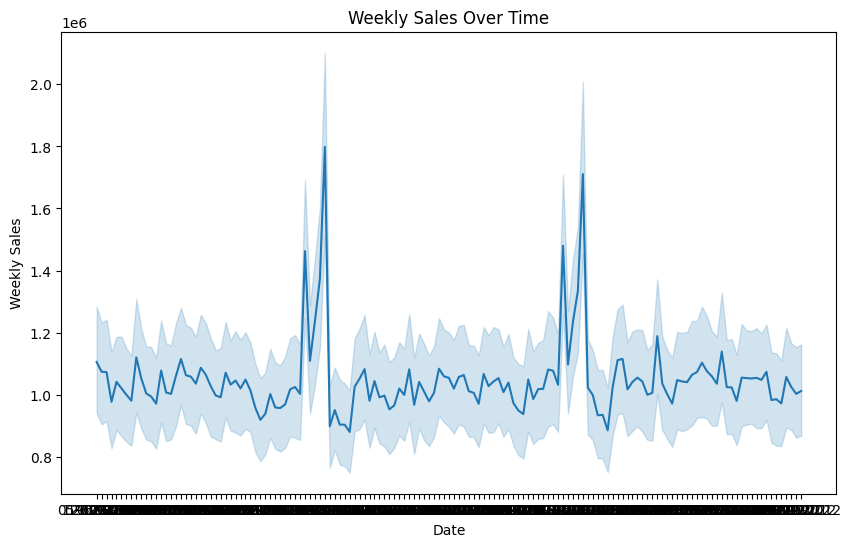

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=data)
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

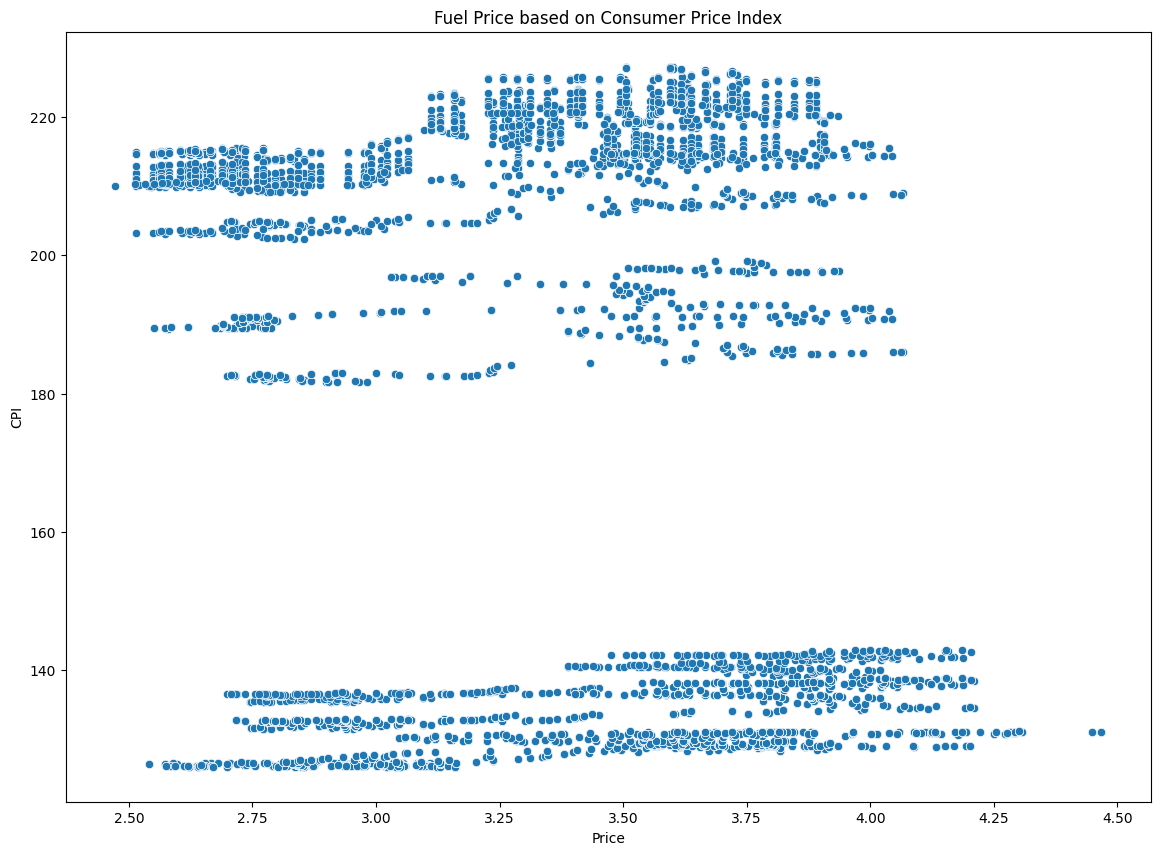

In [11]:
plt.figure(figsize=(14, 10))
sns.scatterplot(x='Fuel_Price', y='CPI', data=data)
plt.title('Fuel Price based on Consumer Price Index')
plt.xlabel('Price')
plt.ylabel('CPI')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

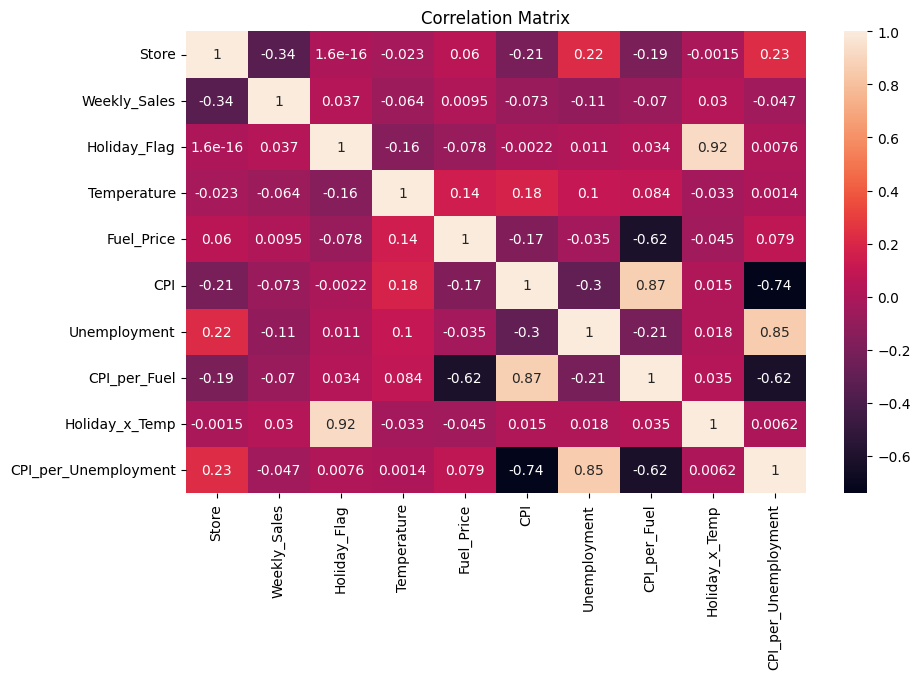

In [12]:
data2 = data.copy()
data3 = data2.drop('Date', axis=1)
#corr = data.select_dtypes(exclude='Date').corr()

plt.figure(figsize=(10,6))
sns.heatmap(data3.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show

#data3.info()

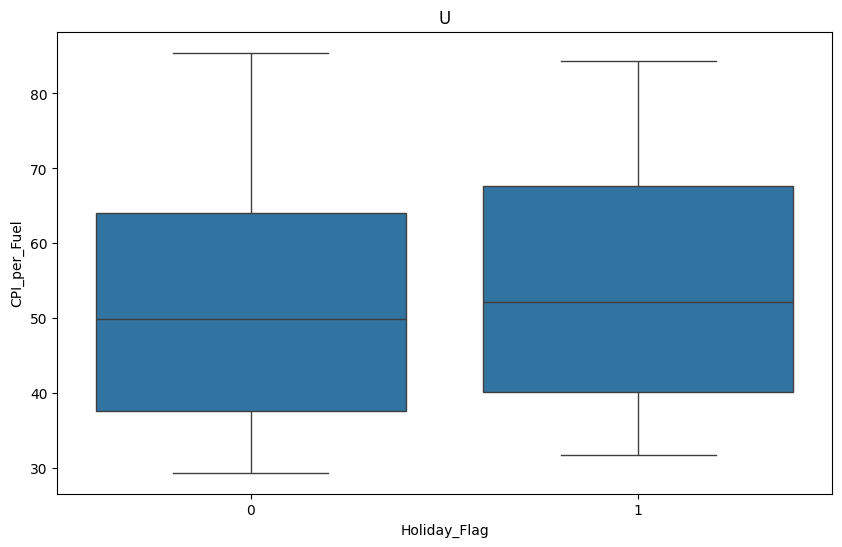

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(y='CPI_per_Fuel', x='Holiday_Flag', data=data)
plt.xlabel('Holiday_Flag')
plt.ylabel('CPI_per_Fuel')
plt.title('U')
plt.show()

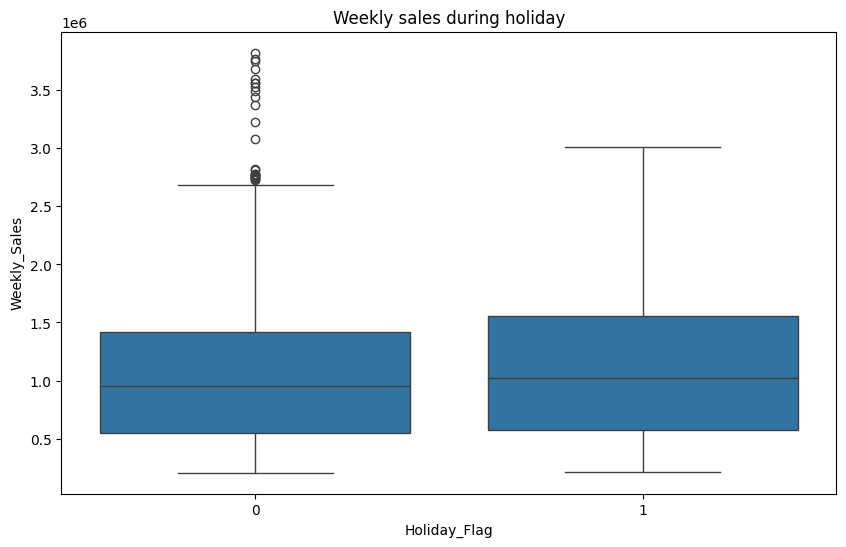

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(y='Weekly_Sales', x='Holiday_Flag', data=data)
plt.ylabel('Weekly_Sales')
plt.xlabel('Holiday_Flag')
plt.title('Weekly sales during holiday')
plt.show()

### Dropping target variable

In [15]:
X_data = data3.drop(columns=['Weekly_Sales'])
y = data3['Weekly_Sales']

if you scale before dropping you introduce data leakage

### Split features to X_train and X_test

In [16]:
from sklearn.model_selection import train_test_split

# Split data for general use. These X_train, X_test will be further processed for LSTM.
# y_train_for_sklearn and y_test_for_sklearn will be used specifically for sklearn models
# to avoid sample size inconsistencies caused by LSTM's windowing.
X_train, X_test, y_train_for_sklearn, y_test_for_sklearn = train_test_split(X_data, y,
                                                    test_size=0.2, shuffle=False)


# Scaling

Scale only X_train

,count,mean,std,min,25%,50%,75%,max
Store,5148.0,-2.415404e-17,1.000097,-1.694017,-0.846971,0.000075,0.847120,1.694166
Holiday_Flag,5148.0,8.281384e-18,1.000097,-0.292214,-0.292214,-0.292214,-0.292214,3.422150
Temperature,5148.0,8.833476e-17,1.000097,-3.192458,-0.722797,0.039924,0.750484,2.247184
Fuel_Price,5148.0,7.066781e-16,1.000097,-1.765165,-0.948155,-0.055040,0.858220,2.313169
CPI,5148.0,2.208369e-17,1.000097,-1.143210,-0.998726,0.308764,1.050060,1.406000
Unemployment,5148.0,2.760461e-16,1.000097,-2.159499,-0.525885,-0.085001,0.236610,3.265291
CPI_per_Fuel,5148.0,2.208369e-16,1.000097,-1.501619,-0.897417,-0.208513,0.857239,2.072446
Holiday_x_Temp,5148.0,5.520923e-18,1.000097,-0.270478,-0.270478,-0.270478,-0.270478,6.746804
CPI_per_Unemployment,5148.0,-1.325021e-16,1.000097,-1.329898,-0.762189,-0.264523,0.515386,3.076218


,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,CPI_per_Fuel,Holiday_x_Temp,CPI_per_Unemployment
Store,1.000000,0.000022,-0.024175,0.055224,-0.209588,0.225030,-0.193669,-0.001535,0.226240
Holiday_Flag,0.000022,1.000000,-0.167625,-0.066369,0.001452,-0.002106,0.029567,0.925616,-0.002052
Temperature,-0.024175,-0.167625,1.000000,0.054796,0.172197,0.177042,0.126435,-0.050621,0.047744
Fuel_Price,0.055224,-0.066369,0.054796,1.000000,-0.171823,0.014071,-0.610383,-0.053708,0.110239
CPI,-0.209588,0.001452,0.172197,-0.171823,1.000000,-0.300201,0.873265,0.018984,-0.744616
Unemployment,0.225030,-0.002106,0.177042,0.014071,-0.300201,1.000000,-0.238711,0.016705,0.849867
CPI_per_Fuel,-0.193669,0.029567,0.126435,-0.610383,0.873265,-0.238711,1.000000,0.040840,-0.640849
Holiday_x_Temp,-0.001535,0.925616,-0.050621,-0.053708,0.018984,0.016705,0.040840,1.000000,0.003573
CPI_per_Unemployment,0.226240,-0.002052,0.047744,0.110239,-0.744616,0.849867,-0.640849,0.003573,1.000000


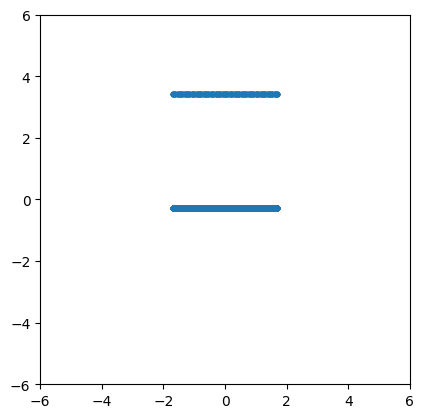

In [17]:

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

df_X1_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)
display(df_X1_data.describe().T)
display(df_X1_data.corr())

plt.plot( X_train_scaled[:,0], X_train_scaled[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### Principal Component Analysis

PCA on X_train

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

## Models

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=1, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=100, weights='uniform'),
    DecisionTreeRegressor(max_depth=2),
    DecisionTreeRegressor(max_depth=5),
    DecisionTreeRegressor(max_depth=10),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=100, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
]

In [20]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=False)

X_train.columns = X_train.columns.astype(str) # Convert column names to strings

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_train, y_train_for_sklearn, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.580274,0.061887,0.506593,0.539715,0.568833,0.632691,0.653536



KNeighborsRegressor(n_neighbors=1)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.292229,0.111103,0.178127,0.186824,0.292666,0.376771,0.426759



KNeighborsRegressor(n_neighbors=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.272274,0.023931,0.242358,0.260438,0.266642,0.288848,0.303085



RandomForestRegressor(max_depth=10)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.147652,0.050899,0.068654,0.141635,0.14941,0.171717,0.206844



GradientBoostingRegressor(max_depth=2)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.335187,0.013934,0.320179,0.323471,0.333328,0.34844,0.350517


#Grid Search CV

In [21]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

X_train.columns = X_train.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_train_pca, y_train_for_sklearn)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.24440502680795656),
  'Best Params': {'n_neighbors': 5, 'weights': 'distance'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.25519968115943803),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 100}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.24690327939233261),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_samples_leaf': 10,
   'n_estimators': 200}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.273718309073843),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.5732397069189137),
  'Best Params': {'fit_intercept': True}}]

## Parismony

In [22]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_train, y_train_for_sklearn)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances = importances[:10]

features_rf = importances.index

X_pars = X_train[ features_rf ]
importances

,0
Store,0.524728
CPI_per_Unemployment,0.175351
CPI,0.143493
Unemployment,0.056668
CPI_per_Fuel,0.055592
Temperature,0.023859
Fuel_Price,0.011858
Holiday_x_Temp,0.007663
Holiday_Flag,0.000789


## VIF

In [23]:
!pip install statsmodels

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_pars_with_const = sm.add_constant(X_pars)

vif = pd.Series(
    [variance_inflation_factor(X_pars_with_const.values, i) for i in range(X_pars_with_const.shape[1])],
    index=X_pars_with_const.columns
).sort_values(ascending=False)

vif[:10]

,0
const,1303.156919
CPI_per_Unemployment,86.348953
CPI_per_Fuel,55.934920
CPI,48.984687
Unemployment,42.601474
Fuel_Price,13.592439
Holiday_Flag,7.791088
Holiday_x_Temp,7.584561
Temperature,1.279165
Store,1.253389


In [25]:
# Copy dataset to avoid modifying the original
X_vif = X_pars.copy()
while True:
  X_vif_with_const = sm.add_constant(X_vif)

  # Compute VIF for all features
  vif_series = pd.Series(
  [variance_inflation_factor(X_vif_with_const.values, i) for i in range(X_vif_with_const.shape[1])],
  index=X_vif_with_const.columns
    )
  #Exclude constant term
  vif_series = vif_series.drop('const', errors='ignore')
  highest_vif_feature = vif_series.idxmax()
  # Break the loop if all features have VIF ≤ 10
  if vif_series.loc[highest_vif_feature] <= 10:  # Checking the first feature after 'const'
    break

  # Drop the feature with the highest VIF
  X_vif = X_vif.drop(columns=[highest_vif_feature])

  print(f"Dropped: {highest_vif_feature} (VIF={vif_series.loc[highest_vif_feature]:.2f})")
  # end


vif_series[:25]

Dropped: CPI_per_Unemployment (VIF=86.35)
Dropped: CPI_per_Fuel (VIF=53.31)


,0
Store,1.080621
CPI,1.235118
Unemployment,1.212996
Temperature,1.228510
Fuel_Price,1.046166
Holiday_x_Temp,7.576886
Holiday_Flag,7.784367


### Training a Linear Regression Model with VIF-Selected Features

In [26]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            "subsample": [0.8, 1.0],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=False)

X_train.columns = X_train.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    # Fit on the original scaled features, not PCA-transformed data, as requested,
    # and use y_train_for_sklearn for consistent sample size.
    grid_search.fit(X_train_scaled, y_train_for_sklearn)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.3125396042730067),
  'Best Params': {'n_neighbors': 1, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.14300190847616706),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 10,
   'min_samples_split': 2,
   'n_estimators': 100}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.16105092368736118),
  'Best Params': {'learning_rate': 0.1,
   'max_depth': 5,
   'min_samples_leaf': 5,
   'n_estimators': 200,
   'subsample': 1.0}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.16988390118312027),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 10,
   'min_samples_split': 5}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.5802737261381246),
  'Best Params': {'fit_intercept': True}}]

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler # Import StandardScaler for VIF-specific scaling

# Select the VIF-selected features from the original X_train and X_test DataFrames
X_train_vif_selected = X_train[X_vif.columns]
X_test_vif_selected = X_test[X_vif.columns]

# Create a NEW scaler specifically for the VIF-selected features
vif_scaler = StandardScaler()
X_train_vif_scaled = vif_scaler.fit_transform(X_train_vif_selected)
X_test_vif_scaled = vif_scaler.transform(X_test_vif_selected)

# Train a Linear Regression model using the VIF-selected and scaled features
lreg_vif = LinearRegression()
lreg_vif.fit(X_train_vif_scaled, y_train_for_sklearn)

# Train a RF Regression model using the VIF-selected and scaled features
RFreg_vif = RandomForestRegressor()
RFreg_vif.fit(X_train_vif_scaled, y_train_for_sklearn)

# Train a GB Regression model using the VIF-selected and scaled features
GBreg_vif = GradientBoostingRegressor()
GBreg_vif.fit(X_train_vif_scaled, y_train_for_sklearn)

# Make predictions on the scaled VIF-selected training and test sets for Linear Regression
y_train_pred_lreg_vif = lreg_vif.predict(X_train_vif_scaled)
y_test_pred_lreg_vif = lreg_vif.predict(X_test_vif_scaled)

# Make predictions on the scaled VIF-selected training and test sets for Random Forest Regression
y_train_pred_rf_vif = RFreg_vif.predict(X_train_vif_scaled)
y_test_pred_rf_vif = RFreg_vif.predict(X_test_vif_scaled)

# Make predictions on the scaled VIF-selected training and test sets for Gradient Boosting Regression
y_train_pred_gb_vif = GBreg_vif.predict(X_train_vif_scaled)
y_test_pred_gb_vif = GBreg_vif.predict(X_test_vif_scaled)

# Calculate and print R-squared values for the model with VIF-selected features
print(f"RF Regression (VIF-selected features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_rf_vif):.4f}")
print(f"RF Regression (VIF-selected features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_rf_vif):.4f}")

print(f"GB Regression (VIF-selected features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_gb_vif):.4f}")
print(f"GB Regression (VIF-selected features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_gb_vif):.4f}")

print(f"Linear Regression (VIF-selected features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_lreg_vif):.4f}")
print(f"Linear Regression (VIF-selected features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_lreg_vif):.4f}")

RF Regression (VIF-selected features) - Train R²:  0.9901
RF Regression (VIF-selected features) - Test  R²:  0.8801
GB Regression (VIF-selected features) - Train R²:  0.8836
GB Regression (VIF-selected features) - Test  R²:  0.9029
Linear Regression (VIF-selected features) - Train R²:  0.1411
Linear Regression (VIF-selected features) - Test  R²:  0.1428


### Prediction on X_test on full set of caled feature (X_train scaled)

In [28]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

y_pred = grid_search.predict(X_test_scaled)  # Using scaled data for test predictions
train_pred = grid_search.predict(X_train_scaled) # Using scaled data for train predictions
print(f"Train R²:  {r2_score(y_train_for_sklearn, train_pred):.4f}") # Use y_train_for_sklearn
print(f"Test  R²:  {r2_score(y_test_for_sklearn, y_pred):.4f}")   # Use y_test_for_sklearn
print(f"Test MAPE: {mean_absolute_percentage_error(y_test_for_sklearn, y_pred):.4f}")

Train R²:  0.2027
Test  R²:  0.1762
Test MAPE: 0.5096


### R-squared for Best Random Forest and Gradient Boosting Models (Full Scaled Features)

To see the R-squared for the best Random Forest and Gradient Boosting models, we need to retrieve their `best_estimator_` from a `GridSearchCV` run using the full scaled feature set (`X_train_scaled`, `X_test_scaled`), similar to how the Linear Regression model was evaluated in the previous cell last so grid_search.predict takes the last processed model. Since the `grid_search` object was overwritten in the loop in cell  we'll perform a separate `GridSearchCV` for each of these models to obtain their respective best estimators.

###Use gradient boost and random forest feature to make prediction

In [41]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Re-define param_grids for clarity or retrieve from original cell if available
# Assuming param_grids from cell 7ag9LwJ44bKx is available in the kernel
# If not, you would need to define it here:
# param_grids = { "RandomForestRegressor": (...), "GradientBoostingRegressor": (...) }

kf = KFold(n_splits=5, shuffle=False)

# --- Best RandomForestRegressor ---f
print("Evaluating Best RandomForestRegressor...")
rf_model, rf_param_grid = param_grids["RandomForestRegressor"]
grid_search_rf = GridSearchCV(rf_model, rf_param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train_for_sklearn)
best_rf_model = grid_search_rf.best_estimator_

y_train_pred_rf = best_rf_model.predict(X_train_scaled)
y_test_pred_rf = best_rf_model.predict(X_test_scaled)

print(f"RandomForestRegressor (Full features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_rf):.4f}")
print(f"RandomForestRegressor (Full features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_rf):.4f}")
print(f"RandomForestRegressor (Full features) - Test MAPE: {mean_absolute_percentage_error(y_test_for_sklearn, y_test_pred_rf):.4f}")

# --- Best GradientBoostingRegressor ---
print("\nEvaluating Best GradientBoostingRegressor...")
gb_model, gb_param_grid = param_grids["GradientBoostingRegressor"]
grid_search_gb = GridSearchCV(gb_model, gb_param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
grid_search_gb.fit(X_train_scaled, y_train_for_sklearn)
best_gb_model = grid_search_gb.best_estimator_

y_train_pred_gb = best_gb_model.predict(X_train_scaled)
y_test_pred_gb = best_gb_model.predict(X_test_scaled)

print(f"GradientBoostingRegressor (Full features) - Train R²:  {r2_score(y_train_for_sklearn, y_train_pred_gb):.4f}")
print(f"GradientBoostingRegressor (Full features) - Test  R²:  {r2_score(y_test_for_sklearn, y_test_pred_gb):.4f}")
print(f"GradientBoostingRegressor (Full features) - Test MAPE: {mean_absolute_percentage_error(y_test_for_sklearn, y_test_pred_gb):.4f}")

Evaluating Best RandomForestRegressor...
RandomForestRegressor (Full features) - Train R²:  0.9323
RandomForestRegressor (Full features) - Test  R²:  0.5607
RandomForestRegressor (Full features) - Test MAPE: 0.1629

Evaluating Best GradientBoostingRegressor...
GradientBoostingRegressor (Full features) - Train R²:  0.9544
GradientBoostingRegressor (Full features) - Test  R²:  0.8257
GradientBoostingRegressor (Full features) - Test MAPE: 0.1366


### LSTM

In [30]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,CPI_per_Fuel,Holiday_x_Temp,CPI_per_Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,82.074789,0.0,0.038400
1,10,05-02-2010,2193048.75,0,54.34,2.962,126.442065,9.765,42.688070,0.0,0.077229
2,37,05-02-2010,536006.73,0,45.97,2.572,209.852966,8.554,81.591355,0.0,0.040762
3,17,05-02-2010,789036.02,0,23.11,2.666,126.442065,6.548,47.427631,0.0,0.051787
4,30,05-02-2010,465108.52,0,39.05,2.572,210.752605,8.324,81.941137,0.0,0.039497


In [31]:
!pip install tensorflow

In [32]:
# Create lagged sequences
window_size = 12  # R² IMPROVEMENT: larger window captures more temporal context
                  # (increased from 10 → 12 weeks)

# BUG FIX 2: Build sequences PER STORE, then concatenate.
# The previous global loop slid a 12-row window across ALL stores concatenated.
# After date-sorting, rows on the same date belong to different stores, so each
# window crossed store boundaries — the LSTM learned cross-store noise instead
# of temporal patterns, giving R² ≈ 0. Building per-store sequences ensures
# every window contains only one store's consecutive weekly history.

X_temp, y_temp, dates_temp = [], [], []

for store_id, store_grp in data.groupby('Store'):
    # Sort this store's rows by date and reset index
    store_grp = store_grp.sort_values('Date').reset_index(drop=True)

    # Use the same X_data columns (no Date, no Weekly_Sales)
    X_store = store_grp.drop(columns=['Date', 'Weekly_Sales']).values
    y_store = store_grp['Weekly_Sales'].values
    d_store = store_grp['Date'].values

    for i in range(len(store_grp) - window_size):
        X_temp.append(X_store[i : i + window_size])           # 12 consecutive weeks, same store
        y_temp.append(y_store[i + window_size])               # target: week after the window
        dates_temp.append(d_store[i + window_size])           # date of target week

X_lstm_sequences   = np.array(X_temp)
y_lstm_sequences   = np.array(y_temp)
dates_lstm_sequences = np.array(dates_temp)

# Sort all sequences by target date so the temporal train/test split
# in the next cell respects chronological order across stores
date_order = np.argsort(pd.to_datetime(dates_lstm_sequences, format='%d-%m-%Y'))
X_lstm_sequences     = X_lstm_sequences[date_order]
y_lstm_sequences     = y_lstm_sequences[date_order]
dates_lstm_sequences = dates_lstm_sequences[date_order]

print(f"X_lstm_sequences shape: {X_lstm_sequences.shape}, y_lstm_sequences shape: {y_lstm_sequences.shape}")

X_lstm_sequences shape: (5895, 12, 9), y_lstm_sequences shape: (5895,)


In [33]:
# one temporal split, used by everyone
split_idx    = int(len(X_lstm_sequences) * 0.8)
X_train_3d   = X_lstm_sequences[:split_idx]       # for LSTM (3D)
X_test_3d    = X_lstm_sequences[split_idx:]
X_train_2d   = X_train_3d.reshape(X_train_3d.shape[0], -1)  # for sklearn + Dense
X_test_2d    = X_test_3d.reshape(X_test_3d.shape[0], -1)
y_train      = y_lstm_sequences[:split_idx]
y_test       = y_lstm_sequences[split_idx:]
dates_train  = dates_lstm_sequences[:split_idx]
dates_test   = dates_lstm_sequences[split_idx:]

print(f"Train: X={X_train_3d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_3d.shape}, y={y_test.shape}")
print(f"Train: X={X_train_2d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_2d.shape}, y={y_test.shape}")
print(f"Train: X={dates_train.shape}, y={y_train.shape}")
print(f"Test:  X={dates_test.shape}, y={y_test.shape}")

Train: X=(4716, 12, 9), y=(4716,)
Test:  X=(1179, 12, 9), y=(1179,)
Train: X=(4716, 108), y=(4716,)
Test:  X=(1179, 108), y=(1179,)
Train: X=(4716,), y=(4716,)
Test:  X=(1179,), y=(1179,)


In [34]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # new update
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

# Define a Keras model (example: a simple LSTM model)
# You will need to adjust the layers and input_shape to match your data and desired architecture
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    Dense(1)
])

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Define the LSTM model building function for cross-validation
def build_lstm_model_cv(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Assuming X_lstm_sequences and y_lstm_sequences are already defined and represent the data to be used
# X_lstm_sequences has shape (n_samples, window_size, n_features)
# y_lstm_sequences has shape (n_samples,)

# Define cross-validation parameters
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

epochs = 150 # adjust this
batch_size = 64 # adjust this

train_mae_cv_list = []
test_mae_cv_list = []
train_r2_cv_list = []
test_r2_cv_list = []

fold = 1
# X_lstm_sequences and y_lstm_sequences are 3D and 1D respectively, but TimeSeriesSplit expects 2D array for X
# We will use X_lstm_sequences_2d and reshape within the loop for LSTM input

# First, reshape X_lstm_sequences to 2D for TimeSeriesSplit
X_lstm_sequences_2d = X_lstm_sequences.reshape(X_lstm_sequences.shape[0], -1)

for train_index, test_index in kf_time_series.split(X_lstm_sequences_2d):
    print(f"Fold {fold}/{n_splits}")

    # Split data for the current fold
    X_train_fold_2d, X_test_fold_2d = X_lstm_sequences_2d[train_index], X_lstm_sequences_2d[test_index]
    y_train_fold, y_test_fold = y_lstm_sequences[train_index], y_lstm_sequences[test_index]

    # Scale X and y within the fold to prevent data leakage
    scaler_X_cv = MinMaxScaler(feature_range=(0, 1))
    scaler_y_cv = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled_2d = scaler_X_cv.fit_transform(X_train_fold_2d)
    X_test_scaled_2d = scaler_X_cv.transform(X_test_fold_2d)

    y_train_scaled = scaler_y_cv.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y_cv.transform(y_test_fold.reshape(-1, 1))

    # Reshape scaled X data to 3D for LSTM input
    current_window_size = X_lstm_sequences.shape[1] # This should be 10
    current_num_features = X_lstm_sequences.shape[2] # This should be 5

    X_train_scaled_3d_cv = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], current_window_size, current_num_features))
    X_test_scaled_3d_cv = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], current_window_size, current_num_features))

    # Build a fresh LSTM model for each fold
    model_lstm_cv = build_lstm_model_cv(current_window_size, current_num_features)

    # Early stopping callback
    early_stopping_cv = EarlyStopping(
        monitor='val_loss',
        patience=25, # Adjusted patience for cross-validation
        restore_best_weights=True
    )

    # Train the model
    history_cv = model_lstm_cv.fit(
        X_train_scaled_3d_cv, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled_3d_cv, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping_cv]
    )

    # Evaluate on training data
    y_train_pred_scaled_cv = model_lstm_cv.predict(X_train_scaled_3d_cv, verbose=0)
    y_train_pred_cv = scaler_y_cv.inverse_transform(y_train_pred_scaled_cv) # Inverse transform predictions
    train_mae_cv = mean_absolute_error(y_train_fold, y_train_pred_cv)
    train_r2_cv = r2_score(y_train_fold, y_train_pred_cv)

    # Evaluate on test data
    y_test_pred_scaled_cv = model_lstm_cv.predict(X_test_scaled_3d_cv, verbose=0)
    y_test_pred_cv = scaler_y_cv.inverse_transform(y_test_pred_scaled_cv) # Inverse transform predictions
    test_mae_cv = mean_absolute_error(y_test_fold, y_test_pred_cv)
    test_r2_cv = r2_score(y_test_fold, y_test_pred_cv)

    print("MAE:")
    print(f"  Train: {train_mae_cv:.4f}")
    print(f"  Test:  {test_mae_cv:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2_cv:.4f}")
    print(f"  Test:  {test_r2_cv:.4f}")
    print()

    train_mae_cv_list.append(train_mae_cv)
    test_mae_cv_list.append(test_mae_cv)
    train_r2_cv_list.append(train_r2_cv)
    test_r2_cv_list.append(test_r2_cv)

    fold += 1
# end

print("\nCross-validation results:")
cv_results_df = pd.DataFrame({
    'Train MAE': train_mae_cv_list,
    'Test MAE': test_mae_cv_list,
    'Train R2': train_r2_cv_list,
    'Test R2': test_r2_cv_list
})
display(cv_results_df)
display(cv_results_df.describe())

Fold 1/5
MAE:
  Train: 112364.5276
  Test:  225856.5090
R^2:
  Train: 0.8576
  Test:  0.6212

Fold 2/5
MAE:
  Train: 123548.0332
  Test:  143582.9867
R^2:
  Train: 0.8348
  Test:  0.7945

Fold 3/5
MAE:
  Train: 131411.9427
  Test:  124200.8882
R^2:
  Train: 0.8065
  Test:  0.8469

Fold 4/5
MAE:
  Train: 121336.0729
  Test:  180795.1276
R^2:
  Train: 0.8367
  Test:  0.7234

Fold 5/5
MAE:
  Train: 114815.6357
  Test:  102081.6942
R^2:
  Train: 0.8386
  Test:  0.8852


Cross-validation results:


,Train MAE,Test MAE,Train R2,Test R2
0,112364.527634,225856.509048,0.857639,0.621179
1,123548.033186,143582.986675,0.834763,0.794473
2,131411.942738,124200.888211,0.806543,0.846857
3,121336.072891,180795.127631,0.836662,0.723361
4,114815.635713,102081.694164,0.838584,0.885245


,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,120695.242432,155303.441146,0.834838,0.774223
std,7539.352234,48900.034955,0.018288,0.104906
min,112364.527634,102081.694164,0.806543,0.621179
25%,114815.635713,124200.888211,0.834763,0.723361
50%,121336.072891,143582.986675,0.836662,0.794473
75%,123548.033186,180795.127631,0.838584,0.846857
max,131411.942738,225856.509048,0.857639,0.885245


In [36]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# define training parameters
epochs          = 350
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.001 # Changed from 0.05 to 0.001 to match CV setup

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define model_lstm_final (moved from a later cell)
window_size = 10 # Assuming this is consistent
num_features = X_train_3d.shape[2] # Corrected: Derive num_features from the actual number of features

model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae'
)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Correctly determine the number of features from the scaled 3D data
num_features = X_train_scaled_3d_cv.shape[2]

# Define the LSTM model with the same architecture as before
model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)), # Use the correctly calculated num_features

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer and compile the model
optimizer = Adam(learning_rate=0.001) # Use the same learning rate as previous LSTM
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=40,          # Stop after 25 epochs without improvement (consistent with previous)
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm_final.summary()

# --- Start of added check for data cardinality ---
#print(f"Checking X_train_scaled_3d shape: {X_train_scaled_3d_cv.shape}")
#print(f"Checking y_train_scaled shape: {y_train_scaled.shape}")

#if X_train_scaled_3d.shape[0] != y_train_scaled.shape[0]:
#    raise ValueError(f"Data cardinality mismatch: X_train has {X_train_scaled_3d.shape[0]} samples, but y_train has {y_train_scaled.shape[0]} samples.")
# --- End of added check for data cardinality ---

# Initialize and fit scaler_y_final with the unscaled y_train_fold from the last CV fold
scaler_y_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final.fit(y_train_fold.reshape(-1, 1))

# Train the model with scaled data
history_lstm_final = model_lstm_final.fit(
    X_train_scaled_3d_cv, y_train_scaled,
    epochs=350, # Use same number of epochs
    batch_size=64, # Reverting batch size
    validation_data=(X_test_scaled_3d_cv, y_test_scaled),
    verbose=1,
    callbacks=[early_stopping]
)

# Get predictions using the final model
y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale
y_train_pred = scaler_y_final.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y_final.inverse_transform(y_test_pred_scaled)

# Inverse transform true values for consistent comparison based on the cv fold
y_train_true_original = y_train_fold
y_test_true_original = y_test_fold

# Calculate metrics for the retrained LSTM model
r2_train = r2_score(y_train_true_original, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true_original, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true_original, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true_original, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 10, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,577 (127.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1386 - val_loss: 0.1244
Epoch 2/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1129 - val_loss: 0.1204
Epoch 3/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1052 - val_loss: 0.1062
Epoch 4/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0992 - val_loss: 0.0971
Epoch 5/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0949 - val_loss: 0.1027
Epoch 6/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0919 - val_loss: 0.0793
Epoch 7/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0894 - val_loss: 0.0753
Epoch 8/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0853 - val_loss: 0.0771
Epoch 9/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0822 - val_loss: 0.0711
Epoch 10/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0791 - val_loss: 0.0656
Epoch 11/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0768 - val_loss: 0.0607
Epoch 12/350
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


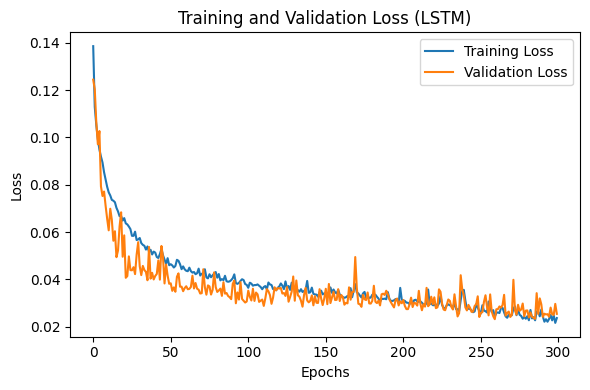

r2_train:   0.93854
r2_test:    0.95115
rmse_train: 1.4188e+05
rmse_test:  1.1765e+05


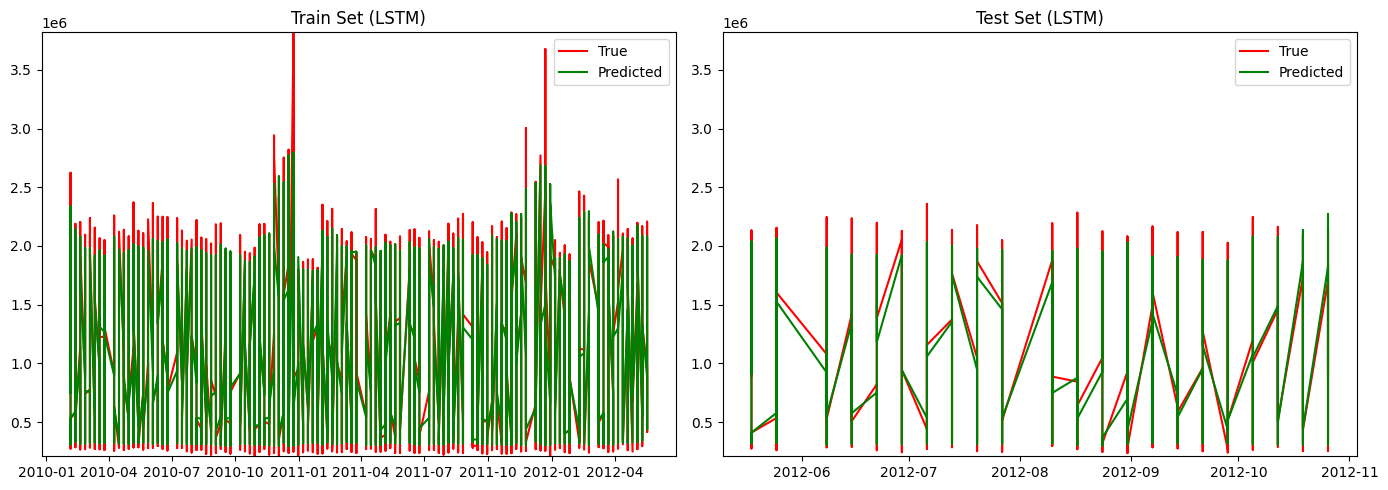

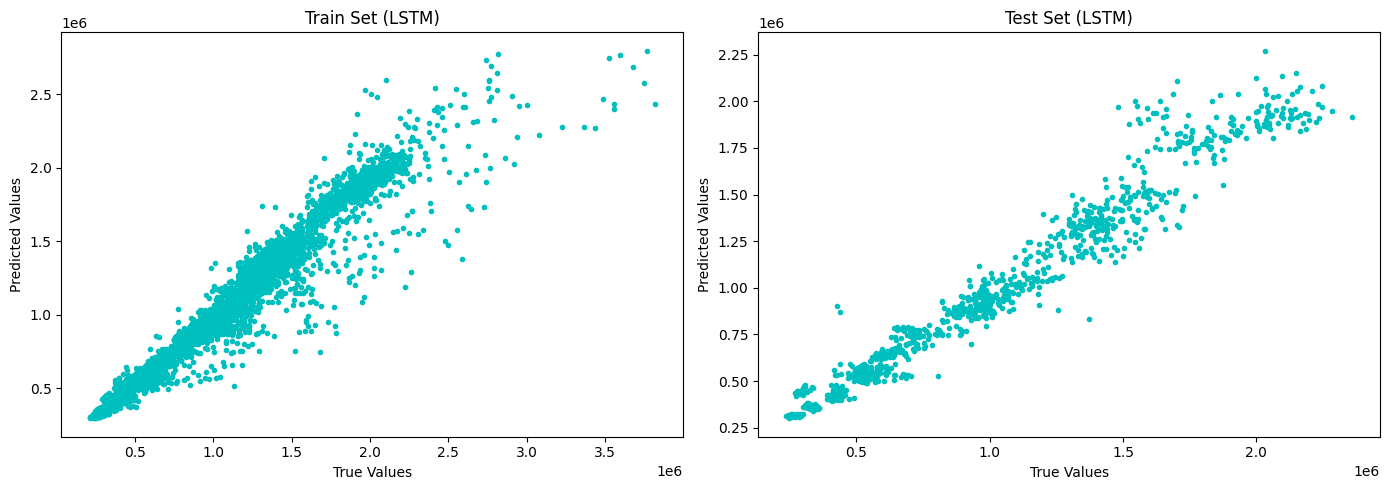

MAE:
  Train: 79903.2441
  Test:  83665.7665
R^2:
  Train: 0.9385
  Test:  0.9512


In [38]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

# Re-initialize these variables to ensure they hold the correct data
# X_lstm_sequences_2d, y_lstm_sequences, dates_lstm_sequences are available from cell 5g6G-EnM0UV1
X_for_split = X_lstm_sequences_2d
y_for_split = y_lstm_sequences
dates_for_split = dates_lstm_sequences

n_splits = 5 # Assuming n_splits is 5 as used in previous CV
kf_time_series_reget = TimeSeriesSplit(n_splits=n_splits)

last_train_index = None
last_test_index = None
last_y_train_fold = None
last_y_test_fold = None
last_scaler_y_cv = None

# Iterate through the splits to get the data and scaler for the last fold
for i, (tr_idx, ts_idx) in enumerate(kf_time_series_reget.split(X_for_split)): # Use X_for_split here
    if i == n_splits - 1: # This is the last fold which is fold 5
        last_train_index = tr_idx
        last_test_index = ts_idx
        last_y_train_fold = y_for_split[tr_idx] # Use y_for_split here (numerical target)
        last_y_test_fold = y_for_split[ts_idx]  # Use y_for_split here (numerical target)

        # Recreate scaler_y_cv for the last fold to ensure consistency
        temp_scaler_y_cv = MinMaxScaler(feature_range=(0,1))
        temp_scaler_y_cv.fit(last_y_train_fold.reshape(-1, 1)) # This should now work with numerical data
        last_scaler_y_cv = temp_scaler_y_cv
        break

# NOTE: X_train_scaled_3d_cv, y_train_scaled, X_test_scaled_3d_cv, y_test_scaled
# and history_lstm_final are from the training of the final model in the previous cell (EKLhmJsQ6UOS),
# which used the data from the *last fold* of the cross-validation setup in 4WyL7OHF27oO.
# So, these variables are already aligned with the 'last fold' logic.

y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale using the correct scaler_y_cv
y_train_pred = last_scaler_y_cv.inverse_transform(y_train_pred_scaled)
y_test_pred  = last_scaler_y_cv.inverse_transform(y_test_pred_scaled)

# Now use the true values and dates from the last fold's split
y_train_true = last_y_train_fold.reshape(-1, 1)
y_test_true = last_y_test_fold.reshape(-1, 1)
dates_train_plot = dates_for_split[last_train_index] # Use dates_for_split
dates_test_plot = dates_for_split[last_test_index]   # Use dates_for_split

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm_final.history['loss'], label='Training Loss')
ax.plot(history_lstm_final.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Convert dates to datetime objects for proper plotting on x-axis
y_train_pred_series.index = pd.to_datetime(y_train_pred_series.index, format='%d-%m-%Y')
y_test_pred_series.index = pd.to_datetime(y_test_pred_series.index, format='%d-%m-%Y')
dates_train_plot = pd.to_datetime(dates_train_plot, format='%d-%m-%Y')
dates_test_plot = pd.to_datetime(dates_test_plot, format='%d-%m-%Y')

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")